# Examen: Manejo de técnicas de PLN para entender un corpus de datos

**Ricardo Calvo Perez - A01028889**

In [21]:
import os

Extraemos el corpus de nuestro archivo `.txt`. En nuestro caso, decidimos usar el libro de Alicia en el país de las maravillas. Para esto, usamos os para obtener nuestra variable de entorno, donde está almacenada la ruta completa hacia nuestra carpeta de NLP, y posteriormente la juntamos con la dirección donde se encuentra guardado el libro en el formato correspondiente.

In [22]:
base_path = os.getenv("NAT_LANG_PATH")
corpus = os.path.join(
    base_path,
    'Data',
    'AliceAdventuresInWonderland.txt'
)

En este apartado cargamos el libro (_Alicia en el país de las maravillas_), especificado por la ruta `corpus`.

Se quiso tener un alcance diferente de un simple copiado línea por línea a un preprocesamiento básico diseñado para optimizar futuros análisis de lenguaje natural (NLP).

El proceso de carga y limpieza se realiza en varios pasos dentro del bucle principal. Utilizamos `re.sub(r'[*_]', '', line)` para eliminar los caracteres `*` y `_` del texto original, ya que no son relevantes para el análisis del contenido lingüístico.

En lugar de guardar líneas individuales (que pueden cortarse a mitad de oración), hice un sistema de `text_buffer` (acumulador de texto). Este sistema acumula texto de varias líneas hasta encontrar un delimitador de oración (`. `), lo cual es bastante simple pero funcional, dándonos a entender que terminó una oración.

Usamos `re.split(r'[.]\s', text_buffer)` para dividir el texto acumulado en oraciones completas y coherentes.

La condición `if sentence.strip():` garantiza que solo se añadan a la lista `raw_corpus` oraciones que contengan texto útil, evitando entradas vacías o compuestas únicamente de espacios.

El resultado es una lista (`raw_corpus`) donde cada elemento es una oración completa y limpia.

Finalmente, el script imprime estadísticas básicas del corpus procesado (número de oraciones y ejemplos de las primeras/últimas 5) y guarda el corpus limpio en un nuevo archivo (`ProcessedCorpus.txt`) por si queremos ver las modificaciones que se hicieron basándonos en el corpus original.


In [23]:
import re

In [24]:
raw_corpus = []
text_buffer = ""

with open(corpus, 'r', encoding='utf-8') as f:
    for line in f:
        # Remove formatting characters
        line = re.sub(r'[*_]', '', line)

        # Add the cleaned line to the buffer, with a space to separate words
        text_buffer += line.strip() + " "

        # Split by the delimiter ('. ')
        # The split consumes the delimiter, so we restore the period afterward
        parts = re.split(r'[.]\s', text_buffer)

        # Iterate over all parts except the last one (which is the incomplete remainder)
        for i in range(len(parts) - 1):
            sentence = parts[i].strip()
            if sentence:  # Ensure the sentence is not empty
                # Rebuild the sentence by adding the period we removed
                raw_corpus.append(sentence + ".")

        # Keep only the last part (the remainder) for the next iteration
        text_buffer = parts[-1]

    # After finishing the loop, process any remaining text in the buffer
    if text_buffer.strip():
        raw_corpus.append(text_buffer.strip())

print(f'The corpus has {len(raw_corpus)} lines.')
print('\nFirst 5 lines: ')
for line in raw_corpus[:5]:
    print(line)

print('\nLast 5 lines: ')
for line in raw_corpus[-5:]:
    print(line)

# Save the processed corpus to a new file
output_path = os.path.join(base_path, 'Data', 'ProcessedCorpus.txt')
with open(output_path, 'w', encoding='utf-8') as f:
    for line in raw_corpus:
        f.write(line + '\n')

print(f'\nProcessed corpus saved to: {output_path}')


The corpus has 906 lines.

First 5 lines: 
The Project Gutenberg eBook of Alice's Adventures in Wonderland  This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever.
You may copy it, give it away or re-use it under the terms of the Project Gutenberg License included with this ebook or online at www.gutenberg.org.
If you are not located in the United States, you will have to check the laws of the country where you are located before using this eBook.
Title: Alice's Adventures in Wonderland  Author: Lewis Carroll  Release date: June 27, 2008 [eBook #11] Most recently updated: June 26, 2025  Language: English  Credits: Arthur DiBianca and David Widger   START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND  [Illustration]     Alice’s Adventures in Wonderland  by Lewis Carroll  THE MILLENNIUM FULCRUM EDITION 3.0  Contents  CHAPTER I.
Down the Rabbit-Hole CHAPTER II.

Last 5 line

## 1. Genere una visualización utilizando la ley de Zipf para ver la calidad del corpus a analizar. Justifique la calidad del corpus en base al grafico presentado.

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

Para construir la gráfica de Zipf utilizamos `CountVectorizer` porque nos permite transformar el corpus directamente en una matriz de frecuencias sin encargarnos manualmente del tokenizado. Con el parámetro `token_pattern=r"(?u)\b\w+\b"` controlamos exactamente qué se considera una palabra, evitando que símbolos o caracteres aislados alteren el conteo y asegurando que la frecuencia refleje el vocabulario real del corpus.

Una vez vectorizado el texto, obtener las frecuencias totales es tan simple como aplicar `X_bow.sum(axis=0).A1`, lo que nos da un arreglo limpio con la aparición total de cada palabra. A partir de ahí, ordenamos dichas frecuencias de mayor a menor mediante `np.sort`, lo cual es indispensable porque la ley de Zipf se basa precisamente en comparar la posición (rango) con la frecuencia. El rango lo generamos con `np.arange`, que nos da una secuencia consecutiva que coincide con la posición ordenada de cada palabra.

Para visualizar la relación, usamos `plt.loglog`, ya que la distribución de Zipf solo se revela correctamente en una escala logarítmica doble. El gráfico en esta escala permite ver si las frecuencias siguen una tendencia de potencia. Finalmente, agregamos la cuadrícula con `plt.grid` para facilitar la lectura de la caída y la alineación del comportamiento del vocabulario.

Cada una de estas funciones se eligió porque simplifica pasos que de otro modo serían manuales y propensos a errores, permitiendo pasar del corpus a la representación visual de forma directa, consistente y sin perder fidelidad en el proceso.


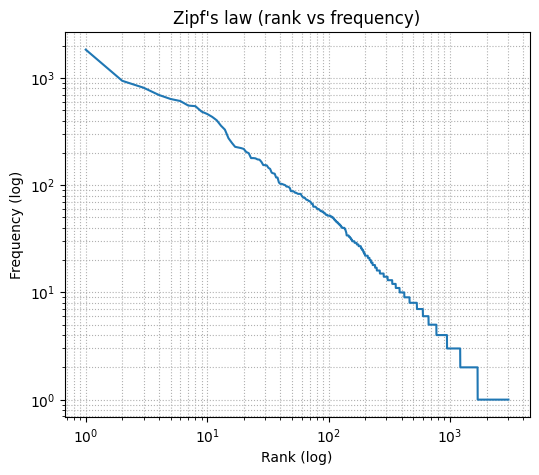

In [26]:
cv = CountVectorizer(binary=False, token_pattern=r"(?u)\b\w+\b")
X_bow = cv.fit_transform(raw_corpus)
freq = X_bow.sum(axis=0).A1

sorted_freq = np.sort(freq)[::-1]
ranks = np.arange(1, len(sorted_freq)+1)

# Plot log-log
plt.figure(figsize=(6,5))
plt.loglog(ranks, sorted_freq)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf's law (rank vs frequency)")
plt.grid(True, which="both", linestyle=":")
plt.show()


## 2. Contar el número total de palabras en el corpus.


Para obtener el número total de palabras en el corpus aprovechamos directamente el arreglo de frecuencias que ya habíamos calculado en el paso anterior. En lugar de volver a procesar el texto o recorrer manualmente los documentos, utilizamos `freq.sum()`, que acumula todas las apariciones individuales de cada palabra en el vocabulario. Esta operación es precisa y eficiente porque `freq` contiene exactamente la frecuencia total de cada término del corpus, resultado del proceso previo de vectorización.

Usamos `sum()` en el arreglo ya que nos entrega en un solo paso la cantidad total de palabras presentes en el corpus completo, sin duplicar trabajo ni volver a tokenizar. 


In [27]:
total_words = freq.sum()
print(f"Total number of words in the corpus: {total_words}")

Total number of words in the corpus: 30577


## 3. Contar la cantidad de palabras únicas en el texto.

Para obtener la cantidad de palabras únicas aprovechamos nuevamente la estructura generada por la vectorización. La matriz de bolsa de palabras construida anteriormente crea una columna por cada término distinto detectado en el corpus, por lo que el arreglo `freq`  que contiene la frecuencia total de cada palabra mantiene una posición por cada una de esas entradas únicas.

En lugar de recalcular vocabularios o volver a tokenizar el texto, usamos `freq.shape[0]`, que nos da directamente el número de elementos del arreglo, es decir, la cantidad total de palabras únicas presentes en el corpus. Esta forma de obtener el resultado es inmediata, coherente con el procesamiento ya realizado y evita repetir trabajo de análisis léxico. 


In [28]:
print(f"Total number of unique words in the corpus: {freq.shape[0]}")

Total number of unique words in the corpus: 3030


## 4. Contar el número de palabras que comienzan con letras mayúsculas.

Para contar las palabras que comienzan con mayúscula, primero extraímos todas las palabras del corpus mediante `re.findall`, lo que nos permitió trabajar con una lista limpia sin signos de puntuación ni separadores erróneos. Luego, dentro del bucle principal, verificamos si cada palabra es alfabética con `isalpha()` y examinamos su primer carácter usando `isupper()`. Esto nos permite identificar de forma precisa solo aquellas palabras que realmente inician con una letra mayúscula y evitar falsos positivos derivados de números o símbolos. El contador se incrementa únicamente cuando la condición se cumple, garantizando un cálculo exacto.

In [29]:
all_words = []

for sentence in raw_corpus:
    # Extract all sequences of alphanumeric characters interpreted as words
    # \b marks word boundaries; \w+ matches letters, digits, and underscores
    words_list = re.findall(r'\b\w+\b', sentence)

    # Add the extracted words to the global list
    all_words.extend(words_list)


total_uppercase_words = 0
total_lowercase_words = 0

for palabra in all_words:
    # Process only alphabetic words (ignore numbers or mixed tokens)
    if palabra.isalpha():

        # Count how many words start with an uppercase letter
        # palabra[0] gives the first character
        if palabra[0].isupper():
            total_uppercase_words += 1

        # Count how many words start with a lowercase letter
        elif palabra[0].islower():
            total_lowercase_words += 1


# Display the number of words starting with uppercase letters
print(f"Total number of words that start with uppercase in the corpus: {total_uppercase_words}")


Total number of words that start with uppercase in the corpus: 4034


## 5. Contar el número de palabras que comienzan con letras minúsculas.

Para las palabras que comienzan con minúscula seguimos el mismo recorrido, aprovechando el mismo bucle para no repetir procesamiento innecesario. En este caso, después de descartar elementos no alfabéticos, se usa `islower()` para determinar si la palabra inicia con una letra minúscula. De esta manera se clasifica cada término sin volver a recorrer el corpus ni volver a tokenizarlo, manteniendo consistencia y eficiencia en el análisis.

In [30]:
print(f"Total number of words that starts in lowercase in the corpus: {total_lowercase_words}")

Total number of words that starts in lowercase in the corpus: 26439


## 6. Contar la frecuencia de las palabras cerradas (stopwords) en el corpus.

Para contar las stopwords del corpus utilizamos el conjunto de palabras vacías proporcionado por `nltk`, lo que nos asegura trabajar con una lista estándar y ampliamente usada en tareas de NLP. Primero cargamos el recurso con `nltk.download('stopwords')` y luego extraímos todas las palabras de cada oración usando `re.findall`, lo cual nos da un tokenizado básico pero suficiente para este tipo de análisis. A partir de esa lista filtramos únicamente aquellas palabras que, una vez convertidas a minúsculas, aparecen dentro de `stopwords.words('english')`. Este filtrado directo nos permite evitar confusiones entre versiones mayúsculas/minúsculas y detectar correctamente todas las apariciones reales de términos funcionales.

El resultado se acumula en `corpus_stopwords`, donde cada ocurrencia se registra explícitamente. Esto nos permite obtener tanto el total de stopwords presentes en el corpus como la cantidad de stopwords únicas simplemente aplicando `len()` y `len(set())`. Con este enfoque se mantiene un conteo preciso sin necesidad de estructuras adicionales y se reaprovecha el preprocesamiento previo, evitando volver a recorrer o limpiar el corpus de forma innecesaria.


In [31]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
corpus_stopwords = []

for sentence in raw_corpus:
    # Extract all sequences of alphanumeric characters interpreted as words
    words_list = re.findall(r'\b\w+\b', sentence)

    # Filter and keep only the stopwords from the extracted words
    stopword_list = [word.lower() for word in words_list if word.lower() in stopwords.words('english')]

    # Add the filtered stopwords to the global list
    corpus_stopwords.extend(stopword_list)

print(f"Total number of stopwords in the corpus: {len(corpus_stopwords)}")
print(f"Unique stopwords in the corpus: {len(set(corpus_stopwords))}")


Total number of stopwords in the corpus: 16464
Unique stopwords in the corpus: 146


## 7. Identificar y contar las palabras más comunes en el texto

Para identificar las palabras más comunes del corpus aprovechamos directamente la matriz de frecuencias creada previamente. El vector `freq` contiene la cantidad total de apariciones de cada término, por lo que basta con ordenar estos valores para ubicar los más altos. Usamos `np.argsort(freq)` para obtener los índices ordenados por frecuencia y seleccionamos los últimos `N` elementos —los de mayor valor— invirtiendo luego el orden para mostrar los términos más frecuentes primero. Esto evita cualquier cálculo manual y garantiza que el ranking sea exacto y consistente con el procesamiento previo.

Con `cv.get_feature_names_out()` obtenemos el vocabulario en el mismo orden en que fue generado por la vectorización, lo que permite mapear fácilmente los índices seleccionados a las palabras correspondientes. Al extraer `top_terms` y `top_freqs` podemos imprimir las palabras más comunes junto con su frecuencia real. Este procedimiento es directo, fiable y aprovecha completamente la estructura ya construida por el modelo de bolsa de palabras.


In [33]:
vocab = cv.get_feature_names_out()
N = 10
top_idx = np.argsort(freq)[-N:][::-1]
top_terms = vocab[top_idx]
top_freqs = freq[top_idx]

print(f"Top {N} most common words in the corpus:")
for term, count in zip(top_terms, top_freqs):
    print(f"{term}: {count}")

Top 10 most common words in the corpus:
the: 1839
and: 941
to: 811
a: 695
of: 637
it: 610
she: 553
i: 546
you: 486
said: 462


## 8. Identificar y contar la frecuencia de nombres propios en el corpus

Para identificar los nombres propios del corpus utilizamos herramientas de `nltk` que permiten ir más allá del simple análisis por patrones. Primero tokenizamos cada oración con `nltk.word_tokenize`, lo que nos da una separación más precisa que una división manual, ya que esta función respeta puntuación, contracciones y estructuras propias del inglés. Posteriormente aplicamos `nltk.pos_tag`, que asigna una etiqueta gramatical a cada token. Esto nos permite distinguir específicamente los sustantivos propios, ya que `NNP` y `NNPS` corresponden a nombres propios en singular y plural. Con esas etiquetas podemos filtrar únicamente los tokens que representan entidades como personajes, lugares o nombres importantes dentro del texto.

Después del filtrado gramatical se realiza una limpieza ligera para eliminar puntuación adherida al inicio o al final del token, garantizando que el nombre capturado sea exacto. También evitamos incluir símbolos o palabras vacías verificando que el resultado contenga letras. Todos los nombres propios válidos se agregan a la lista `proper_names` preservando su capitalización original. Finalmente, con `Counter` obtenemos las frecuencias de aparición de cada nombre propio, lo que permite identificar cuáles son los personajes y entidades más relevantes según su presencia en el corpus.


In [34]:
from collections import Counter
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [35]:
proper_names = []

for sentence in raw_corpus:
    # Tokenize the sentence into individual tokens
    tokens = nltk.word_tokenize(sentence, language='english')

    # Tag each token with its part of speech
    tagged_words = nltk.pos_tag(tokens)

    for word, tag in tagged_words:
        # Keep only proper nouns (singular or plural)
        if tag in ('NNP', 'NNPS'):

            # Remove trailing punctuation (e.g. '"Alice,' → 'Alice')
            cleaned = re.sub(r'^[^A-Za-z]+|[^A-Za-z]+$', '', word)

            # Skip empty results after cleaning
            if not cleaned:
                continue

            # Skip tokens that do not contain letters (avoids symbols)
            if not any(ch.isalpha() for ch in cleaned):
                continue

            # Keep original capitalization for output
            proper_names.append(cleaned)

# Count frequencies of all collected proper nouns
name_counts = Counter(proper_names)


print("\nMost common proper nouns and their frequencies:")
for name, freq in name_counts.most_common(N):
    print(f"'{name}': {freq} occurrences")

print(f"\nTotal unique proper nouns found: {len(name_counts)}")
print(f"Total proper noun occurrences: {sum(name_counts.values())}")



Most common proper nouns and their frequencies:
'Alice': 398 occurrences
'Gutenberg': 84 occurrences
'Project': 80 occurrences
'Queen': 72 occurrences
'King': 61 occurrences
'Turtle': 59 occurrences
'Mock': 57 occurrences
'Gryphon': 55 occurrences
'Hatter': 53 occurrences
'Rabbit': 42 occurrences

Total unique proper nouns found: 446
Total proper noun occurrences: 2197


## 9. Contar el número total de oraciones en el corpus

Para obtener el número total de oraciones no fue necesario realizar un procesamiento adicional, ya que desde el inicio construimos `raw_corpus` de manera que cada elemento representara una oración completa. Este diseño previo permite que la operación sea directa: basta con usar `len(raw_corpus)` para contar cuántas oraciones contiene el corpus. Esta estrategia evita volver a dividir el texto o aplicar tokenización adicional, aprovechando directamente la estructura ya generada durante el preprocesamiento.


In [36]:
print(f"Total number of sentences in the corpus: {len(raw_corpus)}")

Total number of sentences in the corpus: 906


## 10. Calcular la longitud promedio de las oraciones.

Para calcular la longitud promedio de las oraciones utilizamos directamente la estructura ya organizada en `raw_corpus`, donde cada elemento es una oración completa. Para obtener la longitud en palabras aplicamos `re.findall(r'\b\w+\b', s)` sobre cada oración, lo que nos permite contar únicamente secuencias alfanuméricas interpretadas como palabras, evitando que la puntuación distorsione el resultado. Con esa lista de conteos calculamos el promedio usando `np.mean`, lo que entrega una medida clara del tamaño típico de las oraciones en términos de vocabulario.

De manera complementaria, también medimos la longitud en caracteres tomando simplemente `len(s)` por oración, ya que en este caso no se requiere filtrado: cada oración ya está limpia y delimitada. Computar el promedio con `np.mean` nos da una segunda perspectiva sobre la extensión de las oraciones, útil para entender la complejidad del estilo del texto. Ambas métricas se obtienen sin reprocesar el corpus y reutilizando el preprocesamiento ya realizado.


In [37]:
# Calculate average sentence length in words and characters
sentence_word_counts = [len(re.findall(r'\b\w+\b', s)) for s in raw_corpus]
avg_words_per_sentence = np.mean(sentence_word_counts)

sentence_char_counts = [len(s) for s in raw_corpus]
avg_chars_per_sentence = np.mean(sentence_char_counts)

print(f"Average sentence length: {avg_words_per_sentence:.2f} words")
print(f"Average sentence length: {avg_chars_per_sentence:.2f} characters")

Average sentence length: 33.75 words
Average sentence length: 177.83 characters


## 11. Contar cuántas veces aparecen cada uno de los signos de puntuación.

Para contar la frecuencia de los signos de puntuación definimos primero un patrón con las marcas que nos interesaba rastrear. Usamos `re.findall` porque permite detectar cada aparición individual dentro de cada oración, sin importar su posición ni contexto. Al recorrer `raw_corpus` extraemos todas las coincidencias y las acumulamos en una lista global, lo que nos da un registro exhaustivo de cada signo encontrado en el texto.

Una vez recopiladas todas las marcas utilizamos `Counter`, que facilita agruparlas y obtener la frecuencia de cada tipo de signo sin necesidad de estructuras adicionales. Esto nos permite generar un recuento detallado por símbolo y también calcular el total acumulado de signos de puntuación presentes en el corpus. El procedimiento es directo, preciso y reutiliza la estructura del corpus ya preprocesado sin necesidad de tokenizaciones extra.


In [38]:
punctuation_pattern = r'[.,;:“\'?!()\[\]\{\}]'
all_punctuation_marks = []

for sentence in raw_corpus:
    # find all returns a list with EACH punctuation mark found
    found_marks = re.findall(punctuation_pattern, sentence)
    all_punctuation_marks.extend(found_marks)

# Counter groups and counts all punctuation marks automatically
final_count = Counter(all_punctuation_marks)

print("Detailed punctuation count:")
print("-" * 30)

# Iterate over each unique punctuation mark and its frequency
for mark, freq in final_count.items():
    print(f"Mark '{mark}': {freq} occurrences")

print("-" * 30)
print(f"Total punctuation marks found: {sum(final_count.values())}")


Detailed punctuation count:
------------------------------
Mark ''': 4 occurrences
Mark '.': 1221 occurrences
Mark ',': 2571 occurrences
Mark ':': 246 occurrences
Mark '[': 4 occurrences
Mark ']': 4 occurrences
Mark '?': 204 occurrences
Mark '“': 1128 occurrences
Mark '(': 73 occurrences
Mark ')': 73 occurrences
Mark ';': 193 occurrences
Mark '!': 452 occurrences
------------------------------
Total punctuation marks found: 6173


## 12. Encontrar las palabras más largas en el texto.


Para identificar las palabras más largas del corpus partimos de la lista `all_words`, filtrando únicamente aquellas que son completamente alfabéticas mediante `isalpha()`. Esto elimina números, símbolos y cualquier token que pudiera distorsionar la medición. Luego convertimos la lista en un conjunto para eliminar duplicados, ya que lo relevante en este punto es analizar la variedad léxica y no la frecuencia de aparición.

Con el conjunto limpio de palabras únicas aplicamos una ordenación personalizada usando `sorted` y una función `key` que prioriza primero la longitud negativa —lo que coloca las palabras más largas al inicio— y, en caso de empate, ordena alfabéticamente para mantener consistencia. Al seleccionar las primeras `N` palabras obtenemos un conjunto claro y organizado de los términos más extensos del corpus, junto con su longitud, sin necesidad de recurrir a procesamiento adicional.


In [39]:
# Keep only alphabetic words
alphabetic_words = [w for w in all_words if w.isalpha()]

# Remove duplicates
unique_words = set(alphabetic_words)

# Sort words by length (longest first); tie-breaker: alphabetical order
sorted_by_length = sorted(unique_words, key=lambda w: (-len(w), w.lower()))

# Choose how many longest words you want to see

print(f"Top {N} longest words in the corpus:\n")
for word in sorted_by_length[:N]:
    print(f"{word} — {len(word)} letters")


Top 10 longest words in the corpus:

unenforceability — 16 letters
MERCHANTABILITY — 15 letters
representations — 15 letters
affectionately — 14 letters
contemptuously — 14 letters
disappointment — 14 letters
electronically — 14 letters
identification — 14 letters
Multiplication — 14 letters
nonproprietary — 14 letters


## 13. Contar el número de oraciones interrogativas.


Para contar las oraciones interrogativas analizamos cada elemento de `raw_corpus` buscando la presencia del signo de interrogación. La estrategia consiste en dividir cada oración usando `split('?')`, lo que permite identificar cuántas preguntas podrían estar contenidas en una misma línea. Cada aparición del signo indica una potencial pregunta, así que procesamos todas las partes excepto la última, que corresponde al texto posterior al último `?`.

Para obtener únicamente la parte interrogativa aislamos el fragmento inmediatamente anterior al signo. Utilizamos `re.split` para recortar cualquier narrativa o puntuación previa y conservar únicamente la cláusula que forma la pregunta. Después reconstruimos la pregunta añadiendo nuevamente el `?` y filtramos resultados vacíos o irrelevantes. Cada pregunta válida se agrega a la lista `questions`, lo que permite contabilizar de forma precisa todas las interrogativas presentes en el corpus, incluso cuando aparecen varias dentro de una misma oración original.


In [40]:
questions = []

for sentence in raw_corpus:
    # Split the sentence wherever a '?' occurs
    parts = sentence.split('?')

    # Each '?' indicates one question, so iterate over all but the last part
    for i in range(len(parts) - 1):
        text_before_question = parts[i]

        # Keep only the clause immediately before the '?'
        # We remove preceding narrative by cutting at the last punctuation mark
        # Example: 'Alice thought, "What time is it?' -> 'What time is it?'
        fragment = re.split(r'[.!?“”"]', text_before_question)[-1]

        # Reconstruct the question by adding the '?'
        question_text = fragment.strip() + '?'

        # Avoid empty or extremely short fragments
        if len(question_text.strip()) > 1:
            questions.append(question_text)

print(f"Total number of questions found in the corpus: {len(questions)}")


Total number of questions found in the corpus: 204


## 14. Identificar y extraer entidades como nombres de personas, lugares y organizaciones.


Para extraer entidades nombradas utilizamos el módulo de NER de `nltk`, que requiere varios modelos previamente descargados: tokenizador, etiquetador gramatical y el clasificador de entidades. Estos recursos permiten que el análisis sea lingüísticamente informado y no dependa de simples reglas o patrones manuales. Para cada oración, primero tokenizamos con `word_tokenize`, asegurando una segmentación precisa del texto. Luego aplicamos `pos_tag` para obtener las categorías gramaticales que sirven como base para el reconocimiento de entidades. Con estos datos alimentamos `ne_chunk`, que genera un árbol donde aparecen agrupadas entidades etiquetadas como PERSON, GPE o ORGANIZATION.

Después de obtener el árbol, recorremos sus nodos y seleccionamos únicamente aquellos subárboles que representan entidades reales. Para cada entidad unimos los tokens que la componen y los almacenamos en `collected_entities` bajo su categoría correspondiente. Al final, convertimos cada lista en un `Counter` para obtener sus frecuencias, lo que permite identificar las entidades más recurrentes del texto. Este flujo asegura una extracción precisa, estructurada y respaldada por modelos entrenados específicamente para este tipo de tareas.


In [41]:
from collections import defaultdict

nltk.download('punkt', quiet=True)

nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

True

In [42]:
collected_entities = defaultdict(list)

for sentence in raw_corpus:
    # Tokenize the sentence into words
    tokens = nltk.word_tokenize(sentence, language='english')

    # POS tagging
    tagged_tokens = nltk.pos_tag(tokens)

    # Named Entity Recognition (NER) using ne_chunk
    ne_tree = nltk.ne_chunk(tagged_tokens, binary=False)

    # Traverse the tree and collect entities of interest
    for subtree in ne_tree:
        # Only subtrees with a label are named entities
        if isinstance(subtree, nltk.Tree):
            label = subtree.label()  # e.g., 'PERSON', 'GPE', 'ORGANIZATION'

            if label in ('PERSON', 'GPE', 'ORGANIZATION'):
                # Join all tokens inside the entity span
                entity_name = " ".join(token for token, pos in subtree.leaves())
                collected_entities[label].append(entity_name)

# Convert lists into Counter objects to get frequencies
entities = {
    label: Counter(names) for label, names in collected_entities.items()
}


print(f"\n{N} Most common PERSON entities:")
for name, freq in entities.get('PERSON', Counter()).most_common(N):
    print(f"'{name}': {freq} occurrences")

print(f"\n{N} Most common GPE (locations) entities:")
for name, freq in entities.get('GPE', Counter()).most_common(N):
    print(f"'{name}': {freq} occurrences")

print(f"\n{N} Most common ORGANIZATION entities:")
for name, freq in entities.get('ORGANIZATION', Counter()).most_common(N):
    print(f"'{name}': {freq} occurrences")



10 Most common PERSON entities:
'Alice': 145 occurrences
'Gryphon': 17 occurrences
'Bill': 14 occurrences
'Project': 14 occurrences
'Hatter': 13 occurrences
'Hare': 10 occurrences
'Dinah': 9 occurrences
'Queen': 7 occurrences
'Don': 6 occurrences
'William': 4 occurrences

10 Most common GPE (locations) entities:
'Alice': 38 occurrences
'Gryphon': 16 occurrences
'United States': 15 occurrences
'Pigeon': 6 occurrences
'Wonderland': 5 occurrences
'English': 5 occurrences
'Hearts': 5 occurrences
'French': 4 occurrences
'Pig': 3 occurrences
'King': 3 occurrences

10 Most common ORGANIZATION entities:
'Mock Turtle': 54 occurrences
'Duchess': 42 occurrences
'Dormouse': 37 occurrences
'Caterpillar': 26 occurrences
'Mouse': 26 occurrences
'Gryphon': 22 occurrences
'Cat': 21 occurrences
'Queen': 20 occurrences
'Project': 20 occurrences
'Hatter': 19 occurrences


## 15. Encontrar y extraer todas las citas directas (entre comillas) en el corpus.


Para extraer las citas directas definimos un patrón regular que detecta texto encerrado entre comillas rectas o tipográficas. El uso de `re.finditer` permite capturar cada coincidencia de forma completa, incluyendo las comillas, en lugar de trabajar solo con el contenido interno. Esta elección facilita conservar la cita tal como aparece en el texto original y evita perder información contextual importante, como el tipo de comillas o posibles espacios asociados.

Al recorrer cada oración del corpus, el patrón identifica todas las secuencias entre comillas, incluso cuando contienen varios caracteres o saltos internos gracias al uso del modificador `DOTALL`. Cada fragmento detectado se almacena en la lista `quotes`, después de una limpieza ligera para eliminar posibles espacios externos. Con esta colección completa es posible mostrar ejemplos y contabilizar con precisión cuántas citas directas están presentes en el corpus, sin depender de su longitud ni de su posición dentro de la oración.


In [43]:
quotes = []

# Pattern that captures the FULL quoted string, including the quotes.
# The outer parentheses capture only the content; the full match contains the quotes.
quote_pattern = r'[“"](.*?)[”"]'

for sentence in raw_corpus:
    # finditer lets us access the full match, not only the inside group
    for match in re.finditer(quote_pattern, sentence, flags=re.DOTALL):
        full_quote = match.group(0).strip()   # includes the quotes
        if full_quote:
            quotes.append(full_quote)

print("\nExample extracted quotes WITH quotes:")
for q in quotes[:N]:
    print("-", q)

print(f"\nTotal direct quotes found: {len(quotes)}")



Example extracted quotes WITH quotes:
- “and what is the use of a book,”
- “without pictures or conversations?”
- “Oh dear! Oh dear! I shall be late!”
- “ORANGE MARMALADE”
- “Well!”
- “after such a fall as this, I shall think nothing of tumbling down stairs! How brave they’ll all think me at home! Why, I wouldn’t say anything about it, even if I fell off the top of the house!”
- “I wonder how many miles I’ve fallen by this time?”
- “—yes, that’s about the right distance—but then I wonder what Latitude or Longitude I’ve got to?”
- “I wonder if I shall fall right through the earth! How funny it’ll seem to come out among the people that walk with their heads downward! The Antipathies, I think—”
- “And what an ignorant little girl she’ll think me for asking! No, it’ll never do to ask: perhaps I shall see it written up somewhere.”

Total direct quotes found: 1050


## 16. Detectar y extraer preguntas en el texto.


Para mostrar y analizar las preguntas extraídas no fue necesario volver a recorrer el corpus ni aplicar reglas adicionales, ya que previamente habíamos construido la lista `questions` con cada interrogativa detectada y reconstruida desde el texto original. En este punto simplemente reutilizamos ese trabajo y presentamos los fragmentos ya identificados. Usar `questions[:N]` permite visualizar solo una muestra controlada, manteniendo el resultado claro y manejable. Esta estrategia aprovecha directamente la extracción previa sin repetir procesamiento y garantiza que las preguntas mostradas sean exactamente las mismas que fueron identificadas durante el análisis interrogativo.


In [44]:
print("\nExtracted question fragments:")
for q in questions[:N]:
    print("-", q)


Extracted question fragments:
- Who Stole the Tarts?
- without pictures or conversations?
- Would the fall never come to an end?
- I wonder how many miles I’ve fallen by this time?
- —yes, that’s about the right distance—but then I wonder what Latitude or Longitude I’ve got to?
- Please, Ma’am, is this New Zealand or Australia?
- Do you think you could manage it?
- But do cats eat bats, I wonder?
- Do cats eat bats?
- Do cats eat bats?


## 17. Identificar palabras que tienen más de un significado.


Para identificar palabras con múltiples significados recurrimos a **WordNet**, un léxico digital ampliamente utilizado en lingüística computacional. Aunque esta herramienta no formó parte directa del curso, es uno de los recursos estándar en análisis semántico y está integrado dentro de `nltk`, lo que permite acceder a definiciones, sinónimos y sentidos distintos de una misma palabra. Descargamos tanto `wordnet` como `omw-1.4`, que es un conjunto multilingüe que complementa la base principal y asegura que los synsets estén completos y actualizados. Esto garantiza que la información semántica utilizada provenga de una fuente confiable y estructurada.

Para el análisis, primero limpiamos todas las palabras alfabéticas y las unificamos en minúsculas, lo que evita duplicados y reduce variaciones irrelevantes. Luego, para cada palabra consultamos sus synsets mediante `wn.synsets(word)`. Cada synset representa un posible significado o uso de la palabra dentro de WordNet. Cuando una palabra tiene más de un synset, se considera polisémica. Al detectar estos casos, los guardamos en un diccionario junto con los sentidos asociados. Finalmente imprimimos ejemplos mostrando cuántos significados tiene cada palabra y las definiciones de WordNet. Este procedimiento permite evaluar la riqueza semántica del vocabulario del corpus utilizando una herramienta diseñada específicamente para representar la estructura del significado en inglés.


In [45]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\calvo\AppData\Roaming\nltk_data...


In [46]:
clean_words = {w.lower() for w in all_words if w.isalpha()}

polysemous = {}

# Identify words that have more than one sense in WordNet
for word in clean_words:
    synsets = wn.synsets(word)
    if len(synsets) > 1:
        polysemous[word] = synsets

print(f"Total polysemous words found: {len(polysemous)}\n")

# Display some examples with definitions
for word, synsets in list(polysemous.items())[:N]:
    print(f"Word: {word} — {len(synsets)} meanings")
    for syn in synsets:
        print("   •", syn.definition())


Total polysemous words found: 2535

Word: partners — 5 meanings
   • a person's partner in marriage
   • an associate in an activity or endeavor or sphere of common interest
   • a person who is a member of a partnership
   • provide with a partner
   • act as a partner
Word: behind — 7 meanings
   • the fleshy part of the human body that you sit on
   • having the lower score or lagging position in a contest
   • in or to or toward the rear
   • remaining in a place or condition that has been left or departed from
   • of timepieces
   • in or into an inferior position
   • in debt
Word: pencil — 5 meanings
   • a thin cylindrical pointed writing implement; a rod of marking substance encased in wood
   • graphite (or a similar substance) used in such a way as to be a medium of communication
   • a figure formed by a set of straight lines or light rays meeting at a point
   • a cosmetic in a long thin stick; designed to be applied to a particular part of the face
   • write, draw, or t

## 18. Encontrar los bigramas, trigramas y cuatrigramas más relevantes en el texto.


Para obtener los bigramas, trigramas y cuatrigramas más relevantes del corpus trabajamos directamente con `all_words`, filtrando únicamente las palabras alfabéticas y normalizándolas a minúsculas para evitar duplicados causados por diferencias de capitalización. Esta lista limpia sirve como base para construir n-gramas continuos que representen secuencias reales del texto.

Utilizamos la función `ngrams` de `nltk`, que genera automáticamente pares, tríos o grupos de cuatro palabras consecutivas según el tamaño indicado. Esta herramienta evita implementar manualmente ventanas deslizantes y garantiza que las secuencias se formen respetando el orden real en el corpus. Una vez generados los n-gramas, empleamos `Counter` para contabilizar sus apariciones, lo que permite identificar cuáles son las combinaciones más frecuentes. Finalmente, mostramos los n-gramas más comunes ordenados por frecuencia, proporcionando una visión clara sobre patrones recurrentes, asociaciones léxicas y posibles unidades semánticas del texto.


In [47]:
from nltk.util import ngrams

In [48]:
tokens = [w.lower() for w in all_words if w.isalpha()]

bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))
fourgrams = list(ngrams(tokens, 4))

bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)
fourgram_freq = Counter(fourgrams)

print(f"\nTop {N} most frequent bigrams:")
for ng, freq in bigram_freq.most_common(N):
    print(" ".join(ng), "—", freq)

print(f"\nTop {N} most frequent trigrams:")
for ng, freq in trigram_freq.most_common(N):
    print(" ".join(ng), "—", freq)

print(f"\nTop {N} most frequent four-grams:")
for ng, freq in fourgram_freq.most_common(N):
    print(" ".join(ng), "—", freq)



Top 10 most frequent bigrams:
said the — 210
of the — 167
said alice — 116
in a — 102
in the — 99
project gutenberg — 88
and the — 85
to the — 85
it was — 76
the queen — 73

Top 10 most frequent trigrams:
the mock turtle — 54
the project gutenberg — 33
i don t — 31
the march hare — 30
said the king — 29
the white rabbit — 21
said the hatter — 21
said to herself — 19
said the mock — 19
said the caterpillar — 18

Top 10 most frequent four-grams:
said the mock turtle — 19
she said to herself — 16
the project gutenberg literary — 13
project gutenberg literary archive — 13
gutenberg literary archive foundation — 13
project gutenberg electronic works — 12
a minute or two — 11
in the united states — 10
of the project gutenberg — 10
you won t you — 10


## 19. Identificar cuáles son los temas/tópicos más recurrentes en el texto.


Para identificar los tópicos más recurrentes en el texto utilizamos un modelo de temas LDA (`LdaModel`) de la biblioteca `gensim`, que está diseñado justamente para extraer patrones temáticos a partir de grandes colecciones de documentos. Primero construimos `processed_sentences` a partir de `raw_corpus`: tokenizamos cada oración con `nltk.word_tokenize`, nos quedamos solo con tokens alfabéticos, los pasamos a minúsculas para normalizar y después filtramos stopwords y palabras muy cortas (longitud ≤ 2) que no aportan contenido semántico útil. Este filtrado previo es clave para que el modelo se centre en términos realmente informativos y no en palabras funcionales o ruido.

Con las oraciones ya limpias construimos un `Dictionary` de `gensim`, que asigna un identificador numérico a cada palabra distinta y sirve de puente entre el texto y las representaciones numéricas. A partir de ahí generamos `bow_corpus`, una versión en bolsa de palabras donde cada documento se representa como pares `(id_palabra, frecuencia)`. Este formato es el que consume directamente `LdaModel`, al que le indicamos cuántos tópicos queremos (`num_topics`), cuántas pasadas hacer sobre el corpus (`passes`) y un `random_state` fijo para reproducibilidad. El modelo resultante nos devuelve, para cada tópico, las palabras más representativas junto con su peso, lo que permite interpretar y nombrar los temas dominantes del libro a partir de coocurrencias y patrones estadísticos en lugar de inspección manual.


In [49]:
from gensim import corpora, models

In [50]:
processed_sentences = []
stop_words = set(stopwords.words('english'))

for sentence in raw_corpus:
    # Tokenize the sentence and keep only alphabetic tokens.
    # Convert each word to lowercase to normalize the text.
    words = [w.lower() for w in nltk.word_tokenize(sentence) if w.isalpha()]

    # Remove stopwords (very common words that do not carry meaning)
    # and remove very short words (length <= 2) that are not useful for topic modeling.
    words = [w for w in words if w not in stop_words and len(w) > 2]

    processed_sentences.append(words)

dictionary = corpora.Dictionary(processed_sentences)
bow_corpus = [dictionary.doc2bow(text) for text in processed_sentences]

num_topics = N
lda_model = models.LdaModel(
    bow_corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

print("\nExtracted Topics:")
for idx, topic in lda_model.show_topics(num_topics=num_topics, formatted=False):
    print(f"\nTopic {idx + 1}:")
    for word, weight in topic:
        print(f"  {word} ({weight:.3f})")


Extracted Topics:

Topic 1:
  said (0.028)
  queen (0.019)
  alice (0.018)
  however (0.008)
  know (0.008)
  began (0.008)
  rather (0.006)
  time (0.006)
  shall (0.006)
  like (0.006)

Topic 2:
  said (0.036)
  alice (0.018)
  little (0.014)
  dormouse (0.014)
  time (0.011)
  march (0.010)
  hare (0.009)
  court (0.006)
  words (0.006)
  round (0.006)

Topic 3:
  alice (0.027)
  thought (0.013)
  like (0.013)
  mouse (0.012)
  little (0.011)
  said (0.010)
  see (0.009)
  think (0.008)
  looked (0.007)
  first (0.007)

Topic 4:
  little (0.017)
  chapter (0.013)
  alice (0.012)
  could (0.012)
  would (0.011)
  quite (0.009)
  bill (0.008)
  work (0.007)
  way (0.007)
  caterpillar (0.007)

Topic 5:
  said (0.051)
  alice (0.042)
  gryphon (0.011)
  turtle (0.009)
  mock (0.009)
  replied (0.009)
  know (0.007)
  never (0.007)
  well (0.006)
  time (0.006)

Topic 6:
  alice (0.043)
  said (0.036)
  like (0.013)
  queen (0.010)
  would (0.010)
  cat (0.009)
  one (0.009)
  thought 

## 20. Construir una representación de tipo Bag of Words y TF-IDF  y comparar cuales son las palabras mas relevantes para ambas sin tomar en cuenta las palabras cerradas.


In [58]:
import string

In [60]:
stopwords_en = set(stopwords.words("english"))

cleaner_corpus = []

for line in raw_corpus:
    tokens = nltk.word_tokenize(line)
    clean_tokens = []

    for t in tokens:
        # Remove punctuation around the token
        t = t.strip(string.punctuation)

        # Skip empty and non-alphabetic tokens
        if not t or not t.isalpha():
            continue

        # Skip stopwords
        if t.lower() in stopwords_en:
            continue

        clean_tokens.append(t.lower())

    cleaner_corpus.append(" ".join(clean_tokens))


for line in cleaner_corpus[:N]:
    print(line)


project gutenberg ebook alice adventures wonderland ebook use anyone anywhere united states parts world cost almost restrictions whatsoever
may copy give away terms project gutenberg license included ebook online
located united states check laws country located using ebook
title alice adventures wonderland author lewis carroll release date june ebook recently updated june language english credits arthur dibianca david widger start project gutenberg ebook alice adventures wonderland illustration alice adventures wonderland lewis carroll millennium fulcrum edition contents chapter
chapter ii
pool tears chapter iii
long tale chapter iv
rabbit sends little bill chapter v
advice caterpillar chapter vi
pig pepper chapter vii


In [67]:
X_bow_vec = CountVectorizer(binary=False, token_pattern=r"(?u)\b\w+\b")
X_bow = X_bow_vec.fit_transform(cleaner_corpus)
bow_feature_names = np.array(X_bow_vec.get_feature_names_out())

# Sum counts over all documents to get global frequency for each word
bow_counts = X_bow.sum(axis=0).A1   # convert to 1D numpy array

# Sort word indices by frequency (descending)
bow_sorted_idx = np.argsort(bow_counts)[::-1]

print(f"\nTop {N} most frequent words (Bag of Words):")
for idx in bow_sorted_idx[:N]:
    print(f"{bow_feature_names[idx]} — count: {bow_counts[idx]}")



Top 10 most frequent words (Bag of Words):
said — count: 458
alice — count: 403
little — count: 128
one — count: 103
project — count: 88
like — count: 85
went — count: 83
would — count: 83
know — count: 82
could — count: 78


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [69]:
tfidf_vec = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    sublinear_tf=True,
    use_idf=True,
)
# Fit on TRAIN only; transform TEST with the same vocabulary
tfidf = tfidf_vec.fit_transform(cleaner_corpus)

tfidf_feature_names = np.array(tfidf_vec.get_feature_names_out())

# Aggregate TF-IDF scores across documents to get a global importance per word
tfidf_scores = tfidf.sum(axis=0).A1

# Sort word indices by TF-IDF score (descending)
tfidf_sorted_idx = np.argsort(tfidf_scores)[::-1]

print(f"\nTop {N} most relevant words (TF-IDF):")
for idx in tfidf_sorted_idx[:N]:
    print(f"{tfidf_feature_names[idx]} — tfidf sum: {tfidf_scores[idx]:.4f}")



Top 10 most relevant words (TF-IDF):
said — tfidf sum: 51.5500
alice — tfidf sum: 40.8674
little — tfidf sum: 15.7212
know — tfidf sum: 15.1094
queen — tfidf sum: 14.9047
one — tfidf sum: 14.2005
king — tfidf sum: 14.0818
went — tfidf sum: 13.8247
like — tfidf sum: 13.3505
thought — tfidf sum: 13.0193


## 21. Entrenar un modelo de embeddings y analizar qué palabras presentan mayor similitud semántica con el término clave que ustedes consideren del corpus.



In [70]:
tokenized_for_embeddings_corpus = []

for line in raw_corpus:
    # Tokenize the line using NLTK
    tokens = nltk.word_tokenize(line)

    clean_tokens = []
    for t in tokens:
        # Remove punctuation attached to tokens, e.g. "Alice!" -> "Alice"
        t = t.strip(string.punctuation)

        # Skip empty tokens and non-alphabetic strings
        if not t or not t.isalpha():
            continue

        # Normalize to lowercase
        clean_tokens.append(t.lower())

    if clean_tokens:
        tokenized_for_embeddings_corpus.append(clean_tokens)

# Quick check
for sent in tokenized_for_embeddings_corpus[:N]:
    print(sent)

['the', 'project', 'gutenberg', 'ebook', 'of', 'alice', 's', 'adventures', 'in', 'wonderland', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever']
['you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 'it', 'under', 'the', 'terms', 'of', 'the', 'project', 'gutenberg', 'license', 'included', 'with', 'this', 'ebook', 'or', 'online', 'at']
['if', 'you', 'are', 'not', 'located', 'in', 'the', 'united', 'states', 'you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before', 'using', 'this', 'ebook']
['title', 'alice', 's', 'adventures', 'in', 'wonderland', 'author', 'lewis', 'carroll', 'release', 'date', 'june', 'ebook', 'most', 'recently', 'updated', 'june', 'language', 'english', 'credits', 'arthur', 'dibianca', 'and', 'david', 'widger', 'star

In [73]:
from gensim.models import Word2Vec
import random

In [72]:
w2v_model = Word2Vec(
    sentences=tokenized_for_embeddings_corpus,
    vector_size=100,   # size of embedding vectors
    window=5,          # context window size
    min_count=3,       # ignore words with total frequency < 3
    workers=4,         # number of CPU cores (adjust to your machine)
    sg=1,              # 1 = skip-gram, 0 = CBOW
    epochs=10          # number of training epochs
)


In [75]:
# Get all words in the vocabulary
vocab_words = list(w2v_model.wv.key_to_index.keys())

# Pick a random word as key term
random_key = random.choice(vocab_words)
print("Random key term:", random_key)

print(f"\nMost similar words to '{random_key}':")
for word, sim in w2v_model.wv.most_similar(random_key, topn=10):
    print(f"  {word} — {sim:.4f}")


Random key term: tail

Most similar words to 'tail':
  duck — 0.9940
  considered — 0.9935
  surprise — 0.9934
  slipped — 0.9934
  legs — 0.9932
  sleepy — 0.9931
  repeat — 0.9931
  caught — 0.9929
  pressed — 0.9928
  short — 0.9927


## 22. Generar embeddings contextuales (BERT, por ejemplo) para varias oraciones del corpus y analizar cómo cambia el vector de una misma palabra cuando aparece en contextos diferentes.


In [76]:
from transformers import AutoTokenizer, AutoModel
import torch


In [77]:
# raw_corpus is assumed to be a list of sentences already built in previous steps

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()


# ===== 1. Function to get contextual embedding of a word in a sentence =====
def get_word_embedding_in_sentence(sentence, target_word, tokenizer, model, device, max_length=128):
    # Tokenize the sentence for BERT
    encoded = tokenizer(
        sentence,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        # last_hidden_state has shape: (batch_size, seq_len, hidden_size)
        last_hidden = outputs.last_hidden_state[0]  # (seq_len, hidden_size)

    # Convert token IDs to token strings
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Tokenize the target word to see how BERT splits it into sub-tokens
    target_tokens = tokenizer.tokenize(target_word.lower())

    # Find all positions where the sequence of target_tokens appears in tokens
    # We skip the last position because we need a full span of length len(target_tokens)
    indices_spans = []
    for i in range(len(tokens) - len(target_tokens)):
        if tokens[i:i+len(target_tokens)] == target_tokens:
            indices_spans.append(list(range(i, i+len(target_tokens))))

    if not indices_spans:
        # Target word not found as a contiguous span of tokens
        return None, tokens

    # Take the first occurrence of the target word in this sentence
    span = indices_spans[0]

    # Average embeddings over the sub-token span
    span_embeddings = last_hidden[span]            # (span_len, hidden_size)
    word_embedding = span_embeddings.mean(dim=0)   # (hidden_size,)

    return word_embedding.cpu().numpy(), tokens


target_word = "alice"

sentences_with_target = [s for s in raw_corpus if target_word.lower() in s.lower()]

print(f"Total sentences containing '{target_word}': {len(sentences_with_target)}")

num_sentences_to_analyze = 10
sentences_sample = sentences_with_target[:num_sentences_to_analyze]

print("\nSample sentences with the target word:")
for i, s in enumerate(sentences_sample):
    print(f"\nSentence {i}:")
    print(s)


embeddings = []
valid_sentences = []

for s in sentences_sample:
    emb, toks = get_word_embedding_in_sentence(
        sentence=s,
        target_word=target_word,
        tokenizer=tokenizer,
        model=bert_model,
        device=device,
        max_length=128
    )

    if emb is not None:
        embeddings.append(emb)
        valid_sentences.append(s)

embeddings = np.stack(embeddings, axis=0)

print(f"\nCollected embeddings for {embeddings.shape[0]} occurrences of '{target_word}'.")


def cosine_similarity_matrix(X):
    """
    Compute the cosine similarity matrix for a set of vectors.
    X: numpy array of shape (n_samples, dim)
    """
    # Normalize each vector to unit length
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    # Cosine similarity is the dot product of normalized vectors
    return np.dot(X_norm, X_norm.T)

similarity_matrix = cosine_similarity_matrix(embeddings)


print("\nCosine similarity of each occurrence vs the first one:\n")

for i, sentence in enumerate(valid_sentences):
    sim_to_first = similarity_matrix[0, i]
    print(f"Occurrence {i} — similarity to occurrence 0: {sim_to_first:.4f}")
    print("  Sentence:", sentence[:200], "...\n")


print("Cosine similarity matrix between all occurrences:\n")
print(similarity_matrix)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\calvo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\calvo\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Total sentences containing 'alice': 347

Sample sentences with the target word:

Sentence 0:
The Project Gutenberg eBook of Alice's Adventures in Wonderland  This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever.

Sentence 1:
Title: Alice's Adventures in Wonderland  Author: Lewis Carroll  Release date: June 27, 2008 [eBook #11] Most recently updated: June 26, 2025  Language: English  Credits: Arthur DiBianca and David Widger   START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND  [Illustration]     Alice’s Adventures in Wonderland  by Lewis Carroll  THE MILLENNIUM FULCRUM EDITION 3.0  Contents  CHAPTER I.

Sentence 2:
Alice’s Evidence     CHAPTER I.

Sentence 3:
Down the Rabbit-Hole   Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pic

## 23. Comparar la capacidad de Bag of Words, TF-IDF y embeddings para capturar el significado semántico del texto, utilizando ejemplos del corpus.


In [ ]:
# valid_sentences: sentences where you successfully extracted 'alice' embeddings
# embeddings: BERT embeddings for 'alice' in those sentences
# similarity_matrix: cosine similarity between those embeddings (already computed)
# X_bow, tfidf: BoW and TF-IDF matrices built from cleaner_corpus

# 1) Map each valid sentence back to its index in raw_corpus
indices_in_corpus = [raw_corpus.index(s) for s in valid_sentences]

print("Comparing semantic similarity of 'alice' contexts:")
print("Anchor = occurrence 0\n")

anchor_raw_idx = indices_in_corpus[0]

for k, sent in enumerate(valid_sentences):
    raw_idx = indices_in_corpus[k]

    # BoW similarity between sentence 0 and sentence k
    sim_bow = cosine_similarity(X_bow[anchor_raw_idx], X_bow[raw_idx])[0, 0]

    # TF-IDF similarity between sentence 0 and sentence k
    sim_tfidf = cosine_similarity(tfidf[anchor_raw_idx], tfidf[raw_idx])[0, 0]

    # BERT similarity for the word 'alice' between occurrence 0 and k
    sim_bert = similarity_matrix[0, k]

    print(f"Occurrence {k}:")
    print("Sentence:", sent[:200], "...")
    print(f"  BoW    similarity vs 0: {sim_bow:.4f}")
    print(f"  TF-IDF similarity vs 0: {sim_tfidf:.4f}")
    print(f"  BERT   similarity vs 0: {sim_bert:.4f}")
    print("-" * 70)


## 24. Evaluar cuál representación de las vistas en clase permite un mejor desempeño en una tarea sencilla de clasificación, como identificar oraciones interrogativas.

## 25. Visualizar en un grafo de coocurrencia los puntos donde cambia los temas a lo largo del texto.


## 26. Aplicar las metricas de centralidad vistas en clase para determinar topicos relevantes sobre el grafo del punto previo.
### - Degree
### - Closeness
### - Betweenness


## Proponer alguna tecnica de machine learning para agrupar texto (k-means, hearchical clustering, etc). hablando del proposito de esto para entender un corpus de datos.